# Model Comparison: MIMIC-II, Credit, CA Housing, FICO

Extracted data from paper table. Models: Log./Linear Reg., CART, NAMs, EBMs, XGBoost, DNNs.
Metrics: AUC (higher better) for classification; RMSE (lower better) for regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extracted data from table (mean ± std)
models = ["Log./Linear Reg.", "CART", "NAMs", "EBMs", "XGBoost", "DNNs"]

data = {
    "MIMIC-II (AUC)": {"mean": [0.791, 0.768, 0.830, 0.835, 0.844, 0.832], "std": [0.007, 0.008, 0.008, 0.007, 0.006, 0.009]},
    "Credit (AUC)": {"mean": [0.975, 0.956, 0.980, 0.976, 0.981, 0.978], "std": [0.010, 0.004, 0.002, 0.009, 0.008, 0.003]},
    "CA Housing (RMSE)": {"mean": [0.728, 0.720, 0.562, 0.557, 0.532, 0.492], "std": [0.015, 0.006, 0.007, 0.009, 0.014, 0.009]},
    "FICO (RMSE)": {"mean": [4.344, 4.900, 3.490, 3.512, 3.345, 3.324], "std": [0.056, 0.113, 0.081, 0.095, 0.071, 0.092]},
}

# Build DataFrame for display
rows = []
for i, model in enumerate(models):
    row = {"Model": model}
    for ds, v in data.items():
        row[ds] = f"{v['mean'][i]:.3f} ± {v['std'][i]:.3f}"
    rows.append(row)
df_display = pd.DataFrame(rows)

print("Extracted table (mean ± std):")
display(df_display)

Extracted table (mean ± std):


,Model,MIMIC-II (AUC),Credit (AUC),CA Housing (RMSE),FICO (RMSE)
0,Log./Linear Reg.,0.791 ± 0.007,0.975 ± 0.010,0.728 ± 0.015,4.344 ± 0.056
1,CART,0.768 ± 0.008,0.956 ± 0.004,0.720 ± 0.006,4.900 ± 0.113
2,NAMs,0.830 ± 0.008,0.980 ± 0.002,0.562 ± 0.007,3.490 ± 0.081
3,EBMs,0.835 ± 0.007,0.976 ± 0.009,0.557 ± 0.009,3.512 ± 0.095
4,XGBoost,0.844 ± 0.006,0.981 ± 0.008,0.532 ± 0.014,3.345 ± 0.071
5,DNNs,0.832 ± 0.009,0.978 ± 0.003,0.492 ± 0.009,3.324 ± 0.092


In [2]:
# DataFrames with numeric mean/std for plotting
df_means = pd.DataFrame({"Model": models})
df_stds = pd.DataFrame({"Model": models})
for ds, v in data.items():
    df_means[ds] = v["mean"]
    df_stds[ds] = v["std"]

# Which datasets are AUC (higher better) vs RMSE (lower better)
auc_datasets = ["MIMIC-II (AUC)", "Credit (AUC)"]
rmse_datasets = ["CA Housing (RMSE)", "FICO (RMSE)"]

## Grouped bar chart by dataset

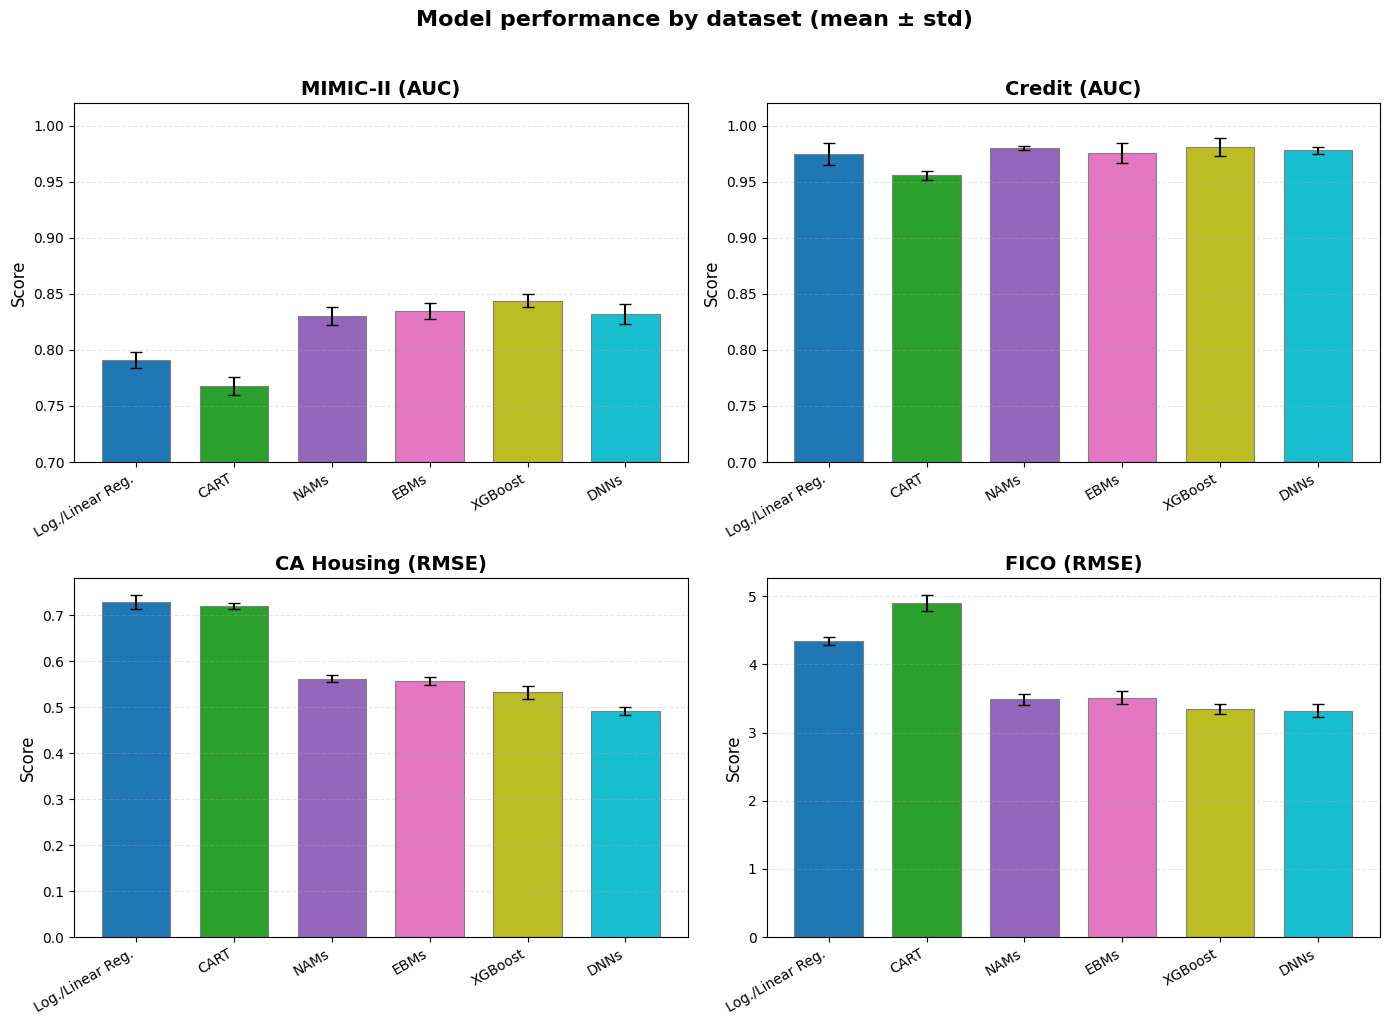

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
x = np.arange(len(models))
width = 0.7

for ax, ds in enumerate(df_means.columns[1:]):
    means = df_means[ds].values
    stds = df_stds[ds].values
    bars = axes[ax].bar(x, means, width, yerr=stds, capsize=4, color=colors, edgecolor="gray", linewidth=0.8)
    axes[ax].set_xticks(x)
    axes[ax].set_xticklabels(df_means["Model"], rotation=30, ha="right", fontsize=12)
    axes[ax].set_ylabel("Score", fontsize=14)
    axes[ax].set_title(ds, fontsize=16, fontweight="bold")
    axes[ax].grid(axis="y", alpha=0.3, linestyle="--")
    if "AUC" in ds:
        axes[ax].set_ylim(0.7, 1.02)
    axes[ax].tick_params(axis="both", labelsize=12)

plt.suptitle("Model performance by dataset (mean ± std)", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Normalized performance difference relative to NAMs

Signed normalized Δ = (other − NAMs) / NAMs. Ordered by primary comparison (mean of normalized deltas).
- **AUC**: positive = other better than NAMs.
- **RMSE**: positive = other has higher RMSE = NAMs better.

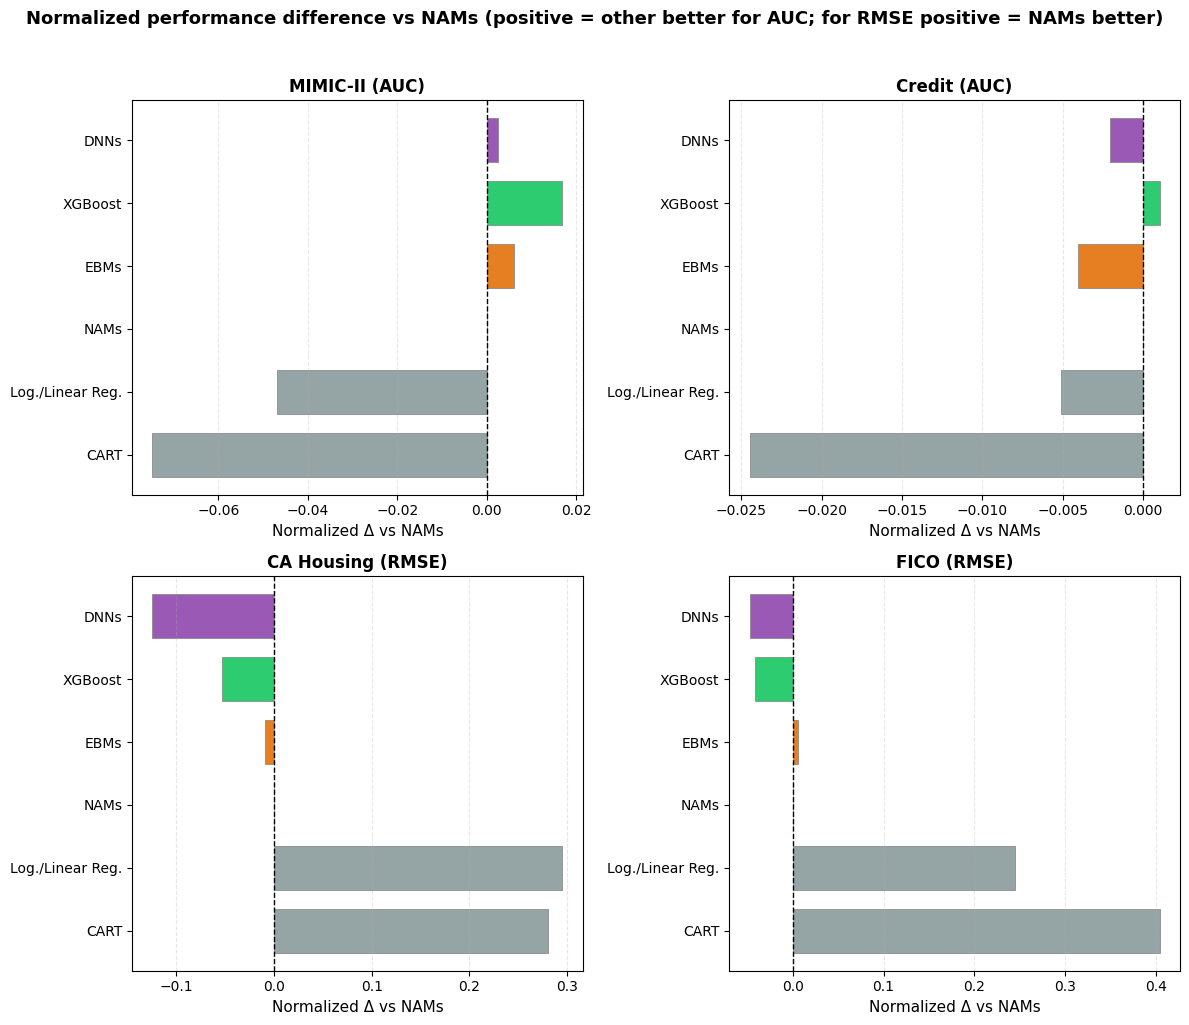

In [4]:
nam_idx = models.index("NAMs")

# Normalized deltas vs NAMs per dataset: (other - NAM) / NAM (avoid div by zero)
deltas = {}
for ds in df_means.columns[1:]:
    nam_val = df_means[ds].iloc[nam_idx]
    if nam_val == 0:
        nam_val = np.nan
    deltas[ds] = (df_means[ds].values - df_means[ds].iloc[nam_idx]) / nam_val

df_delta = pd.DataFrame({"Model": models})
for ds in deltas:
    df_delta[ds] = deltas[ds]

# Primary comparison: mean of absolute deltas (across datasets) for ordering models
# Order datasets by signed normalized Δ (mean delta across models, or by NAMs comparison)
# Here we order models by mean normalized delta (so "others vs NAMs" ordering)
delta_cols = [c for c in df_delta.columns if c != "Model"]
df_delta["primary_delta"] = df_delta[delta_cols].mean(axis=1)
df_delta_sorted = df_delta.sort_values("primary_delta", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

model_colors = {"NAMs": "#3498db", "EBMs": "#e67e22", "XGBoost": "#2ecc71", "DNNs": "#9b59b6", "Log./Linear Reg.": "#95a5a6", "CART": "#95a5a6"}

for ax, ds in enumerate(delta_cols):
    y_pos = np.arange(len(df_delta_sorted))
    vals = df_delta_sorted[ds].values
    cols = [model_colors.get(m, "#7f8c8d") for m in df_delta_sorted["Model"]]
    axes[ax].barh(y_pos, vals, color=cols, height=0.7, edgecolor="gray", linewidth=0.5)
    axes[ax].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[ax].set_yticks(y_pos)
    axes[ax].set_yticklabels(df_delta_sorted["Model"], fontsize=12)
    axes[ax].set_xlabel("Normalized Δ vs NAMs", fontsize=14)
    axes[ax].set_title(ds, fontsize=16, fontweight="bold")
    axes[ax].grid(axis="x", alpha=0.3, linestyle="--")
    axes[ax].tick_params(axis="both", labelsize=12)

plt.suptitle("Normalized performance difference vs NAMs (positive = other better for AUC; for RMSE positive = NAMs better)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()